In [13]:
import numpy as np
import pandas as pd

# Step 1: Load the Monthly mean temp data from the CSV URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0, usecols=[0, 1])


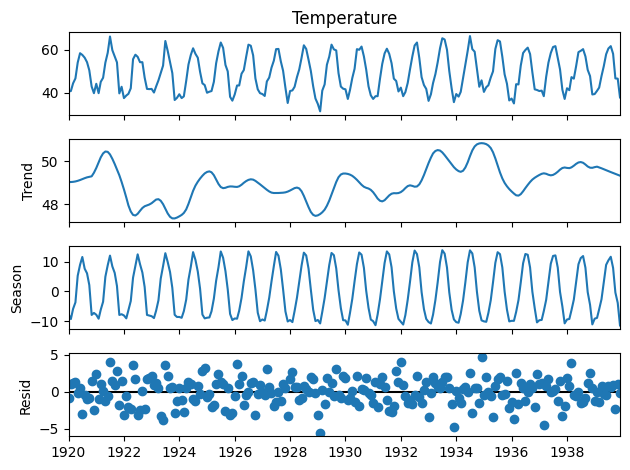

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
# Perform STL decomposition
stl = STL(data['Temperature'], seasonal=11)
result = stl.fit()
# Plot the decomposition
result.plot()
plt.show()


Epoch 1/5


/home/joshmurray/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


179/179 - 3s - 17ms/step - loss: 0.0833
Epoch 2/5
179/179 - 1s - 6ms/step - loss: 0.0461
Epoch 3/5
179/179 - 1s - 6ms/step - loss: 0.0099
Epoch 4/5
179/179 - 1s - 6ms/step - loss: 0.0083
Epoch 5/5
179/179 - 1s - 6ms/step - loss: 0.0091
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


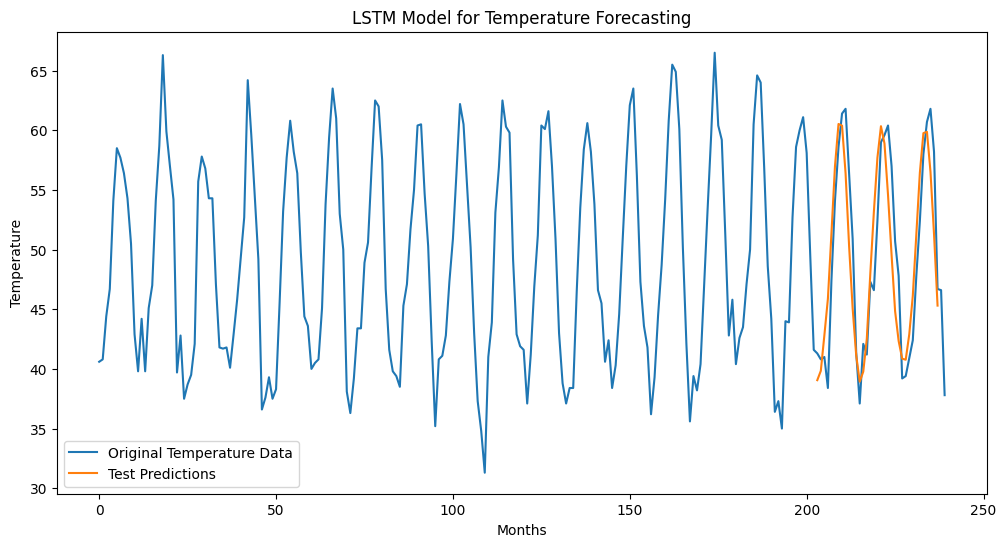

Test RMSE: 2.2443321008081027


In [24]:
#LTSM Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

# Load the Monthly Mean Temperature data from the correct CSV URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'  # Replace with the correct URL
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0)

# Extract the Temperature column
temperature = data['Temperature'].values  # Access the 'Temperature' column

# Preprocess the data
# Reshape and normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
temperature_scaled = scaler.fit_transform(temperature.reshape(-1, 1))

# Split the data into train and test sets
train_size = int(len(temperature_scaled) * 0.8)
train, test = temperature_scaled[:train_size], temperature_scaled[train_size:]

# Function to create dataset with look-back time steps
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 12  # Look back 12 months (1 year)
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape input for LSTM: [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))  # Output layer
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=1, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert predictions and actual values to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform([y_test])

# Plot the results
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(scaler.inverse_transform(temperature_scaled), label='Original Temperature Data')

# Adjust x-axis range for test predictions
test_start = len(train_predict) + (look_back * 2)
plt.plot(np.arange(test_start, len(test_predict) + test_start), test_predict, label='Test Predictions')

# Add labels and legend
plt.xlabel('Months')
plt.ylabel('Temperature')
plt.legend()
plt.title('LSTM Model for Temperature Forecasting')
plt.show()

# Invert the scaling for y_test
y_test_actual = scaler.inverse_transform([y_test]).flatten()    # Flatten to 1D array

# Compute RMSE for test predictions
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict.flatten()))

print(f'Test RMSE: {test_rmse}')


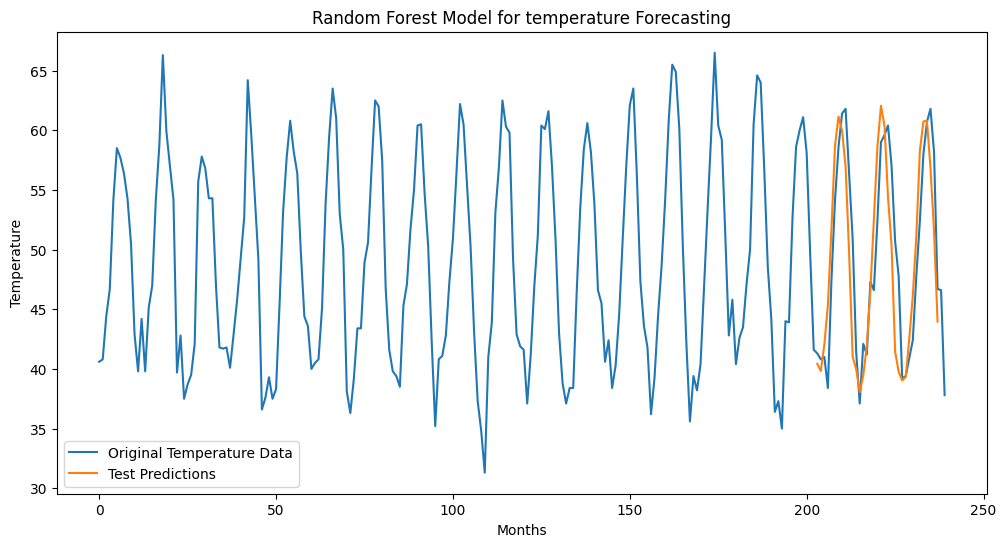

Test RMSE: 2.2760777101973364


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Step 1: Load the Temp data from the correct CSV URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0, usecols=[0, 1])

# Extract the Temp column
temperature = data['Temperature'].values  # Access the 'Temp' column

# Step 2: Preprocess the data
# Reshape and normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
temperature_scaled = scaler.fit_transform(temperature.reshape(-1, 1))

# Split the data into train and test sets
train_size = int(len(temperature_scaled) * 0.8)
train, test = temperature_scaled[:train_size], temperature_scaled[train_size:]

# Function to create dataset with look-back time steps
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])  # Collect look-back values as features
        y.append(dataset[i + look_back, 0])     # Collect the next value as the target
    return np.array(X), np.array(y)

look_back = 12  # Look back 12 months (1 year)
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Flatten the input data to make it 2D (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Flatten the data into 2D
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Step 3: Train the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train_flat, y_train)

# Step 4: Make predictions
train_predict = model_rf.predict(X_train_flat)
test_predict = model_rf.predict(X_test_flat)

# Invert the predictions and actual values to the original scale
train_predict = scaler.inverse_transform(train_predict.reshape(-1, 1))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 5: Plot the results
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(scaler.inverse_transform(temperature_scaled), label='Original Temperature Data')

# Plot test predictions
test_start = len(train_predict) + (look_back * 2)
plt.plot(np.arange(test_start, len(test_predict) + test_start), test_predict, label='Test Predictions')

# Add labels and legend
plt.xlabel('Months')
plt.ylabel('Temperature')
plt.legend()
plt.title('Random Forest Model for temperature Forecasting')
plt.show()

# Compute RMSE for test predictions
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f'Test RMSE: {test_rmse}')


/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


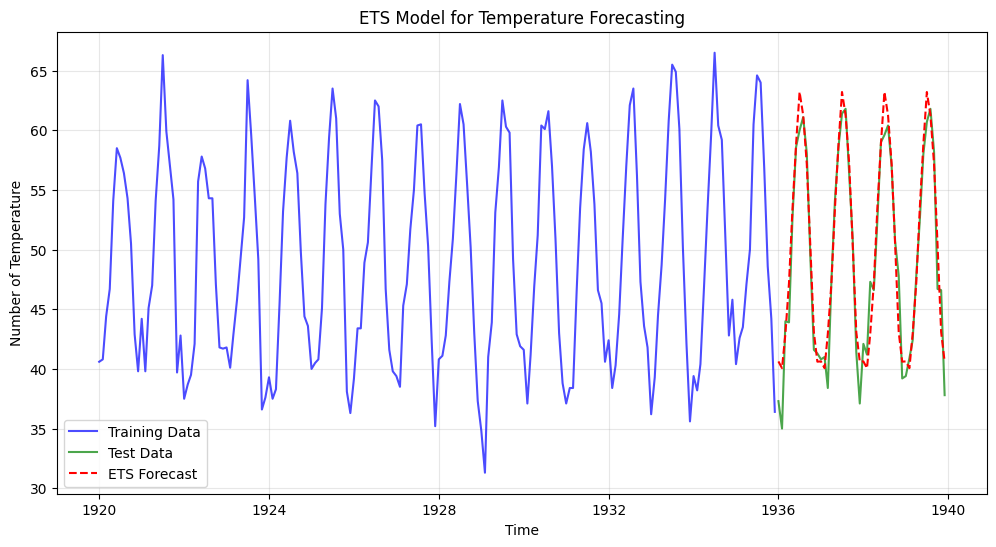

Test RMSE: 2.11


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# Step 1: Load the Temp data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0)

# Step 2: Split into train and test sets (last 20% for testing)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# Step 3: Fit ETS model (Exponential Smoothing)
model = ExponentialSmoothing(
    train['Temperature'],
    seasonal='add',
    seasonal_periods=12,
    trend=None,
    #damped_trend=True,
    #initialization_method='estimated',
    #use_boxcox=True
).fit(
    optimized=True
)

# Step 4: Make forecast for the test period
forecast = model.forecast(len(test))

# Step 5: Plot results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Temperature'], label='Training Data', color='blue', alpha=0.7)
plt.plot(test.index, test['Temperature'], label='Test Data', color='green', alpha=0.7)
plt.plot(test.index, forecast, label='ETS Forecast', linestyle='--', color='red')
plt.xlabel('Time')
plt.ylabel('Number of Temperature')
plt.legend()
plt.title('ETS Model for Temperature Forecasting')
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: Compute and display metrics
test_rmse = np.sqrt(mean_squared_error(test['Temperature'], forecast))
print(f'Test RMSE: {test_rmse:.2f}')


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1375.242, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1028.053, Time=0.29 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1164.546, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2046.902, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1170.744, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=937.815, Time=0.33 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1120.185, Time=0.08 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=914.927, Time=1.27 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=950.802, Time=0.88 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=917.646, Time=0.92 sec
 ARIMA(1,0,1)(2,0,1)[12] intercept   : AIC=

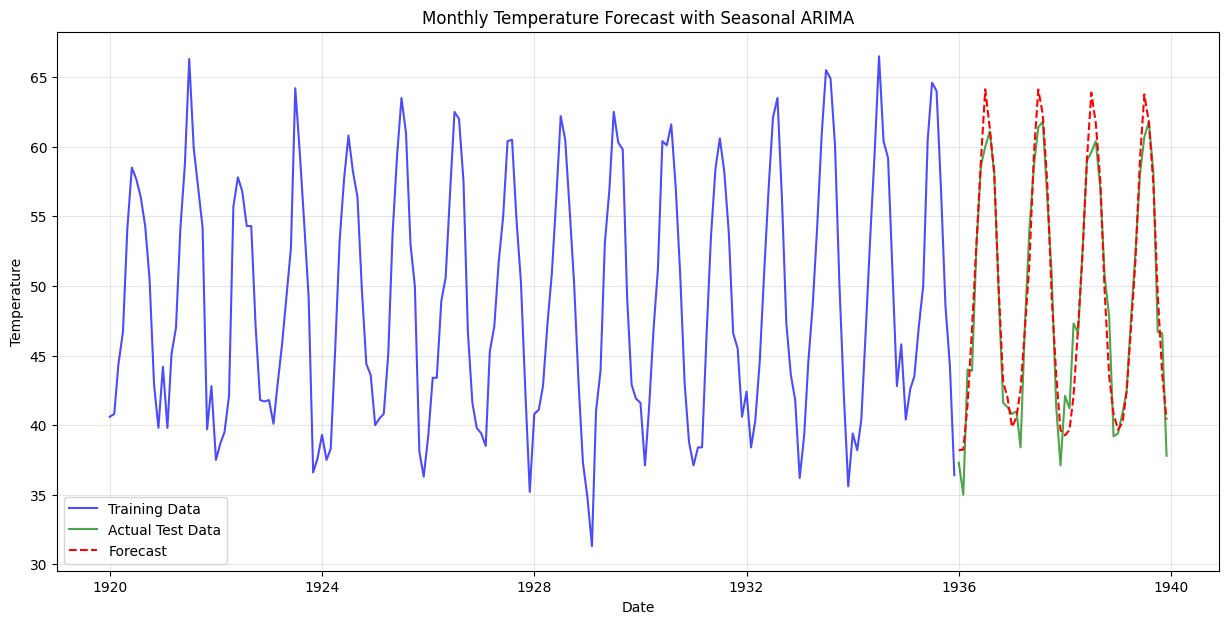

RMSE: 2.10


In [60]:
import pmdarima as pm
import warnings
import pandas as pd
import logging
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ignore warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load and prepare data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
data = pd.read_csv(url, header=0, parse_dates=[0], index_col=0)

# Split into train and test sets
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# Fit Auto ARIMA
model = pm.auto_arima(
    train['Temperature'],
    m=12,  # Monthly seasonality
    seasonal=True,  # Enable seasonality
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic',
    random_state=42
)

# Print model summary
print("\nBest model summary:")
print(model.summary())

# Make predictions
forecast = model.predict(n_periods=len(test), return_conf_int=True)
forecast_mean = forecast[0]
conf_int = forecast[1]

# Plot results
plt.figure(figsize=(15, 7))
plt.plot(train.index, train['Temperature'], label='Training Data', color='blue', alpha=0.7)
plt.plot(test.index, test['Temperature'], label='Actual Test Data', color='green', alpha=0.7)
plt.plot(test.index, forecast_mean, label='Forecast', color='red', linestyle='--')

# Plot confidence intervals
# plt.fill_between(test.index,
#                  conf_int[:, 0],
#                  conf_int[:, 1],
#                  color='red',
#                  alpha=0.1,
#                  label='95% Confidence Interval')

plt.title('Monthly Temperature Forecast with Seasonal ARIMA')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and print metrics
rmse = np.sqrt(mean_squared_error(test['Temperature'], forecast_mean))

print(f'RMSE: {rmse:.2f}')
